[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/robomotic/robotic-hardware/blob/main/notebooks/torque_is_all_you_need.ipynb)

# Torque is all you need

**Purpose:** Understand why torque specs are crucial when buying or designing a robot (and how the same ideas apply to EVs).

**Audience:** Beginners

**Format:** ~45 minutes, light derivations, interactive sliders

## How to use this notebook
- Run cells top to bottom.
- Move sliders to build intuition.
- Keep units in SI: N·m, rad/s, A, V, Ω.

Dependencies used: `numpy`, `matplotlib`, `ipywidgets` only.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, IntSlider, interactive_output, VBox
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)

## 1) What is torque (intuition)?
Torque is rotational force.

- Push a door near the hinge: hard to rotate.
- Push far from the hinge: easy to rotate.

Same force, different distance from pivot => different torque.

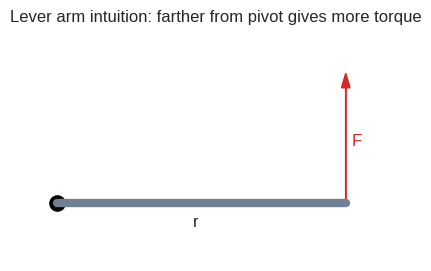

In [2]:
# Simple lever-arm diagram
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot([0, 1.0], [0, 0], linewidth=6, color='slategray')
ax.scatter([0], [0], s=120, color='black', label='Pivot')
ax.arrow(1.0, 0, 0, 0.45, head_width=0.03, head_length=0.05, color='tab:red', length_includes_head=True)
ax.text(1.02, 0.2, 'F', color='tab:red', fontsize=12)
ax.text(0.47, -0.08, 'r', fontsize=12)
ax.set_xlim(-0.1, 1.2)
ax.set_ylim(-0.2, 0.6)
ax.set_aspect('equal')
ax.set_title('Lever arm intuition: farther from pivot gives more torque')
ax.axis('off')
plt.show()

Quick scale examples (order-of-magnitude):
- Human wrist precision tasks: a few N·m
- Car lug nut tightening: around 100+ N·m
- Humanoid robot knee actuators: tens to hundreds of N·m

## 2) Torque equation, formula, and units
The vector form is:

$$\tau = \mathbf{r} \times \mathbf{F}$$

For magnitude:

$$\tau = rF\sin(\theta)$$

where $\theta$ is the angle between $\mathbf{r}$ and $\mathbf{F}$.

SI unit: **N·m** (newton-meter).

In [3]:
def torque_angle_demo(r=0.5, F=20.0):
    theta_deg = np.linspace(0, 180, 361)
    theta_rad = np.deg2rad(theta_deg)
    tau = r * F * np.sin(theta_rad)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(theta_deg, tau, color='tab:blue')
    ax.set_xlabel('Angle θ (deg)')
    ax.set_ylabel('Torque τ (N·m)')
    ax.set_title(f'τ = rFsin(θ), with r={r:.2f} m and F={F:.1f} N')
    ax.axvline(90, color='tab:orange', linestyle='--', label='max at 90°')
    ax.legend()
    plt.show()

torque_angle_controls = {
    'r': FloatSlider(value=0.5, min=0.1, max=1.0, step=0.05, description='r (m)'),
    'F': FloatSlider(value=20.0, min=1.0, max=50.0, step=1.0, description='F (N)')
}
torque_angle_out = interactive_output(torque_angle_demo, torque_angle_controls)
display(VBox([torque_angle_controls['r'], torque_angle_controls['F'], torque_angle_out]))

In [4]:
# Power relation for rotating systems
# P = τω  and  ω = 2π * RPM / 60
rpm = np.array([500, 1000, 2000, 4000])
tau = 50.0  # N·m
omega = 2 * np.pi * rpm / 60
power_w = tau * omega

for r, p in zip(rpm, power_w):
    print(f'RPM={r:4d}, ω={2*np.pi*r/60:7.2f} rad/s, P={p/1000:6.2f} kW')

RPM= 500, ω=  52.36 rad/s, P=  2.62 kW
RPM=1000, ω= 104.72 rad/s, P=  5.24 kW
RPM=2000, ω= 209.44 rad/s, P= 10.47 kW
RPM=4000, ω= 418.88 rad/s, P= 20.94 kW


## 3) How motors produce torque: relation to current, voltage, resistance
A beginner model (good first approximation):

$$\tau = K_T I$$
$$I = \frac{V - K_v\omega}{R}$$

- More current $I$ → more torque
- As speed $\omega$ increases, back-EMF $K_v\omega$ rises → less current available

At $\omega=0$ (stall):
$$\tau_{stall}=K_T\frac{V}{R}$$

### Key motor torque terms

| Term | Definition | Typical use |
|------|------------|-------------|
| **Stall torque** | Torque produced when the shaft is completely stationary ($\omega=0$). The rotor is held — no back-EMF, so current is at maximum: $\tau_{stall}=K_T V/R$. This is the highest torque the motor can generate, but it also means maximum copper heat loss ($P=I^2R$). It **cannot be sustained indefinitely**. | Startup load rating, worst-case static hold |
| **Peak torque** | Maximum torque the controller allows for a **brief window** (typically 1–10 s, vendor-defined). Exceeds continuous rating because the motor's thermal mass absorbs the extra heat for a short time. Always compare vendors on the **same duration window** — a 1 s peak and a 10 s peak are very different. | Jumps, impacts, hard accelerations |
| **Continuous torque** | Torque the motor can produce **indefinitely** without exceeding its thermal design limits. This is the real working capacity. Running above this will cause winding temperature to keep climbing until derating or fault. | Sustained walking, holding a pose, long-duration tasks |

> **Beginner tip:** Marketing materials often highlight peak torque. For real-world robot design, **continuous torque is the number that matters most**.

In [5]:
def dc_motor_curves(V=24.0, R=0.4, Kt=0.08, Kv=0.08):
    # ω range up to slightly above no-load speed
    omega_nl = V / Kv
    omega = np.linspace(0, omega_nl, 300)

    I = (V - Kv * omega) / R
    I = np.clip(I, 0, None)
    tau = Kt * I
    P = tau * omega

    tau_stall = Kt * V / R
    p_peak = P.max()
    omega_p_peak = omega[np.argmax(P)]

    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot(omega, tau, color='tab:blue', label='Torque-speed')
    ax[0].scatter([0], [tau_stall], color='tab:red', zorder=3, label=f'Stall torque={tau_stall:.2f} N·m')
    ax[0].set_xlabel('ω (rad/s)')
    ax[0].set_ylabel('τ (N·m)')
    ax[0].set_title('Torque vs speed')
    ax[0].legend(fontsize=8)

    ax[1].plot(omega, P/1000, color='tab:green', label='Power')
    ax[1].scatter([omega_p_peak], [p_peak/1000], color='tab:orange', zorder=3, label=f'Peak power={p_peak/1000:.2f} kW')
    ax[1].set_xlabel('ω (rad/s)')
    ax[1].set_ylabel('P (kW)')
    ax[1].set_title('Mechanical power vs speed')
    ax[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f'No-load speed ω_nl: {omega_nl:.1f} rad/s')
    print(f'Stall torque τ_stall: {tau_stall:.2f} N·m')
    print('Note: Peak torque is typically limited by controller and thermal constraints.')

dc_motor_controls = {
    'V': FloatSlider(value=24.0, min=6.0, max=80.0, step=1.0, description='V'),
    'R': FloatSlider(value=0.4, min=0.1, max=3.0, step=0.05, description='R (Ω)'),
    'Kt': FloatSlider(value=0.08, min=0.02, max=0.5, step=0.01, description='Kt'),
    'Kv': FloatSlider(value=0.08, min=0.02, max=0.5, step=0.01, description='Kv')
}
dc_motor_out = interactive_output(dc_motor_curves, dc_motor_controls)
display(VBox([dc_motor_controls['V'], dc_motor_controls['R'], dc_motor_controls['Kt'], dc_motor_controls['Kv'], dc_motor_out]))

### Thermal limits and current limits (why peak torque cannot last)

Motor windings are made of copper wire. When current flows through them they dissipate heat:

$$P_{copper} = I^2 R$$

Because torque scales with current ($\tau = K_T I$), more torque means more heat — and heat raises winding temperature. Every motor has a **maximum winding temperature** (e.g. 120 °C for Class F insulation). Exceed it and the insulation degrades or fails.

**How controllers protect the motor:**

1. **Hard current limit** — the inverter is physically unable to push more than $I_{max}$ amps. This sets a ceiling on instantaneous torque regardless of commanded value.
2. **Thermal derating** — as measured (or estimated) temperature rises toward the limit, the controller proportionally reduces the allowed current/torque. You can observe this in the simulation below: at full load, torque eventually falls even though the command stays constant.
3. **Thermal time constant** — the motor's thermal mass ($C_{th}$, J/°C) and thermal resistance ($R_{th}$, °C/W) determine how fast it heats and cools. A high thermal mass buys time for short peaks.

**Practical rule:** Peak torque = available for seconds. Continuous torque = available indefinitely. Always size for continuous, then verify the peak is sufficient for dynamic events.

In [6]:
def thermal_derating_demo(I_cmd=80.0, R=0.12, R_th=0.6, C_th=180.0, T_amb=25.0, T_limit=110.0, Kt=0.08):
    """Simple 1st-order thermal model with current limiting + thermal derating."""
    dt = 0.1
    t = np.arange(0, 600 + dt, dt)  # 10 minutes
    T = np.zeros_like(t)
    T[0] = T_amb

    I_applied = np.zeros_like(t)
    tau = np.zeros_like(t)

    # hard electronic current limit (example)
    I_hard = 120.0

    for k in range(1, len(t)):
        # thermal derating starts near limit
        if T[k-1] < (T_limit - 10):
            I_thermal_max = I_hard
        elif T[k-1] >= T_limit:
            I_thermal_max = 0.35 * I_hard
        else:
            # linear ramp-down in the 10°C window below T_limit
            frac = (T_limit - T[k-1]) / 10.0
            I_thermal_max = (0.35 + 0.65 * frac) * I_hard

        I_applied[k] = np.clip(I_cmd, -I_thermal_max, I_thermal_max)
        tau[k] = Kt * I_applied[k]

        # Heating/cooling model: dT/dt = (I^2R - (T-Tamb)/R_th)/C_th
        p_cu = (I_applied[k] ** 2) * R
        dTdt = (p_cu - (T[k-1] - T_amb) / R_th) / C_th
        T[k] = T[k-1] + dTdt * dt

    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot(t/60, T, label='Winding temp')
    ax[0].axhline(T_limit, color='tab:red', linestyle='--', label='T limit')
    ax[0].set_xlabel('Time (min)')
    ax[0].set_ylabel('Temperature (°C)')
    ax[0].set_title('Thermal behavior')
    ax[0].legend(fontsize=8)

    ax[1].plot(t/60, I_applied, label='Applied current')
    ax[1].plot(t/60, tau, label='Torque (proxy via Kt·I)')
    ax[1].set_xlabel('Time (min)')
    ax[1].set_ylabel('A / N·m')
    ax[1].set_title('Current limit and torque derating')
    ax[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

thermal_controls = {
    'I_cmd': FloatSlider(value=80.0, min=10.0, max=180.0, step=5.0, description='I cmd (A)'),
    'R': FloatSlider(value=0.12, min=0.02, max=0.5, step=0.01, description='R (Ω)'),
    'R_th': FloatSlider(value=0.6, min=0.2, max=2.0, step=0.05, description='R_th'),
    'C_th': FloatSlider(value=180.0, min=40.0, max=500.0, step=10.0, description='C_th'),
    'T_limit': FloatSlider(value=110.0, min=60.0, max=160.0, step=2.0, description='T limit'),
    'Kt': FloatSlider(value=0.08, min=0.02, max=0.3, step=0.01, description='Kt')
}
thermal_out = interactive_output(thermal_derating_demo, thermal_controls)
display(VBox([thermal_controls['I_cmd'], thermal_controls['R'], thermal_controls['R_th'], thermal_controls['C_th'], thermal_controls['T_limit'], thermal_controls['Kt'], thermal_out]))

Reality check:
- Modern EV and humanoid joints often use 3-phase PMSM/BLDC motors + inverter control.
- The simple equations above still give solid first intuition about why current dominates torque at low speed.

## 4) How gears vary torque
For gear ratio $G$ (output torque amplification):

$$\tau_{out} = G\,\eta\,\tau_{in}$$
$$\omega_{out} = \frac{\omega_{in}}{G}$$

where $\eta$ is transmission efficiency. Higher ratio → higher output torque, lower output speed — but total mechanical power is *conserved minus losses*.

### Efficiency ($\eta$)

Real gearboxes dissipate power as heat through friction in gear teeth, bearings, and seals:

$$P_{out} = \eta \cdot P_{in} \quad (\eta < 1)$$

| Gearbox type | Typical $\eta$ | Notes |
|---|---|---|
| Planetary | 95–98% | Widely used in EVs and servo motors |
| Harmonic (strain-wave) drive | 80–90% | Drops to 60–70% at low load or cold temperatures |
| Spur/helical | 97–99% | Efficient but high backlash |

The *efficiency map* on a datasheet shows $\eta$ at different speed/torque combinations. Always check efficiency at **your real operating point**, not the peak-efficiency figure.

### Backlash

When a gearbox reverses direction, gear teeth must travel through a small gap before re-engaging and transmitting torque. This gap is called **backlash**.

- Measured in **arc-minutes** on precision gearbox datasheets (1 arc-min = 1/60°)
- Typical planetary gearbox: 3–10 arc-min
- Precision planetary: < 3 arc-min
- Harmonic drives: < 1 arc-min

**Effect on control:** during the dead-zone, the joint moves without the motor encoder seeing it → position error and force oscillations. For torque-controlled or compliant robot joints, **low backlash is critical**. This is why harmonic drives are the default in high-precision robot joints.

In [7]:
def gear_tradeoff(G=10, eta=0.9, tau_in=2.0, omega_in=300.0):
    tau_out = G * eta * tau_in
    omega_out = omega_in / G

    ratios = np.arange(1, 101)
    tau_curve = ratios * eta * tau_in
    omega_curve = omega_in / ratios

    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot(ratios, tau_curve, color='tab:blue')
    ax[0].scatter([G], [tau_out], color='tab:red', zorder=3)
    ax[0].set_xlabel('Gear ratio G')
    ax[0].set_ylabel('Output torque (N·m)')
    ax[0].set_title('Torque increases with G')

    ax[1].plot(ratios, omega_curve, color='tab:purple')
    ax[1].scatter([G], [omega_out], color='tab:red', zorder=3)
    ax[1].set_xlabel('Gear ratio G')
    ax[1].set_ylabel('Output speed (rad/s)')
    ax[1].set_title('Speed decreases with G')

    plt.tight_layout()
    plt.show()

    print(f'For G={G}, η={eta:.2f}: τ_out={tau_out:.2f} N·m, ω_out={omega_out:.2f} rad/s')

gear_controls = {
    'G': IntSlider(value=10, min=1, max=100, step=1, description='G'),
    'eta': FloatSlider(value=0.9, min=0.7, max=1.0, step=0.01, description='η'),
    'tau_in': FloatSlider(value=2.0, min=0.2, max=20.0, step=0.2, description='τ_in'),
    'omega_in': FloatSlider(value=300.0, min=20.0, max=2000.0, step=20.0, description='ω_in')
}
gear_out = interactive_output(gear_tradeoff, gear_controls)
display(VBox([gear_controls['G'], gear_controls['eta'], gear_controls['tau_in'], gear_controls['omega_in'], gear_out]))

## 5) Motor control strategies
Common strategies:
1. **Speed control**: hold target RPM
2. **Torque control**: command force-like output directly
3. **Position control**: servo to a target angle or trajectory
4. **Impedance/compliance control**: controlled spring-like softness around people

A simple position loop uses PD control:
$$\tau = K_p(\theta_{ref}-\theta) + K_d(\dot\theta_{ref}-\dot\theta)$$

### Encoders

**Encoders** are position sensors mounted on the motor shaft — and sometimes also on the joint output shaft *after* the gearbox. They measure shaft angle; angular velocity is estimated by differencing consecutive readings.

| Encoder type | How it works | Key property |
|---|---|---|
| **Incremental** | Counts pulses as shaft rotates | Needs homing at startup to set absolute reference |
| **Absolute** | Reports exact angle at all times | Works after power cycle — essential for robot boot |

**Resolution** is given in counts-per-revolution (CPR) or bits. A 14-bit encoder gives $2^{14} = 16384$ counts/rev ≈ 0.022° per count. Higher resolution → better velocity estimate → better damping in PD control.

**Dual encoders:** Some robot joints (including Unitree G1/H1 designs) use one encoder on the motor shaft and one on the gearbox output shaft. The angular difference between the two reveals gearbox deflection, from which transmitted torque can be estimated. This is the core principle of a *series elastic actuator*.

### Why PD here, and not full PID?


For many robot joints, **PD** is the default in fast inner loops because it is simple and robust.


- **P** gives restoring torque
- **D** adds damping and reduces oscillation
- **I** can remove steady-state bias, but may cause overshoot and integral windup when actuators saturate


Why many systems avoid strong integral action in inner torque/position loops:
1. Friction and gravity are often handled with feedforward models
2. Torque/current limits create saturation; accumulated integral can destabilize recovery
3. Safety near humans benefits from predictable bounded response


In practice, some systems use a small **I** term in slower outer loops with anti-windup.

In [8]:
def pd_vs_pid_demo(Kp=80.0, Kd=10.0, Ki=0.0, tau_cap=60.0, bias_disturbance=8.0):
    dt = 0.001
    t = np.arange(0, 3.0, dt)
    ref = 1.0
    I_joint = 1.0

    def simulate(use_integral=False):
        theta, omega = 0.0, 0.0
        integ = 0.0
        th = np.zeros_like(t)

        for k in range(len(t)):
            e = ref - theta
            edot = -omega

            if use_integral:
                integ += e * dt
            else:
                integ = 0.0

            tau = Kp * e + Kd * edot + Ki * integ - bias_disturbance
            tau = np.clip(tau, -tau_cap, tau_cap)

            alpha = tau / I_joint
            omega += alpha * dt
            theta += omega * dt
            th[k] = theta

        return th

    th_pd = simulate(use_integral=False)
    th_pid = simulate(use_integral=True)

    plt.figure(figsize=(7, 3.5))
    plt.plot(t, th_pd, label='PD')
    plt.plot(t, th_pid, label='PID (with I term)')
    plt.axhline(ref, color='tab:red', linestyle='--', label='Target')
    plt.xlabel('Time (s)')
    plt.ylabel('Angle (rad)')
    plt.title('PD vs PID under disturbance + torque saturation')
    plt.legend()
    plt.show()

    print('Tip: increase Ki to reduce bias error, then observe overshoot/windup risk under saturation.')

pd_pid_controls = {
    'Kp': FloatSlider(value=80.0, min=5.0, max=300.0, step=1.0, description='Kp'),
    'Kd': FloatSlider(value=10.0, min=0.0, max=80.0, step=0.5, description='Kd'),
    'Ki': FloatSlider(value=0.0, min=0.0, max=120.0, step=1.0, description='Ki'),
    'tau_cap': FloatSlider(value=60.0, min=10.0, max=200.0, step=5.0, description='τ cap'),
    'bias_disturbance': FloatSlider(value=8.0, min=0.0, max=40.0, step=1.0, description='bias')
}
pd_pid_out = interactive_output(pd_vs_pid_demo, pd_pid_controls)
display(VBox([pd_pid_controls['Kp'], pd_pid_controls['Kd'], pd_pid_controls['Ki'], pd_pid_controls['tau_cap'], pd_pid_controls['bias_disturbance'], pd_pid_out]))

In [ ]:
def pd_joint_response(Kp=80.0, Kd=8.0, theta_ref=1.0, t_end=3.0):
    dt = 0.001
    n = int(t_end / dt)

    # Simple 1-DOF inertia model: I*theta_ddot = tau
    I = 1.0
    theta = 0.0
    omega = 0.0

    t_hist = np.zeros(n)
    th_hist = np.zeros(n)

    for i in range(n):
        e = theta_ref - theta
        edot = 0.0 - omega
        tau = Kp * e + Kd * edot
        alpha = tau / I

        omega += alpha * dt
        theta += omega * dt

        t_hist[i] = i * dt
        th_hist[i] = theta

    plt.figure(figsize=(7, 3.5))
    plt.plot(t_hist, th_hist, label='θ(t)')
    plt.axhline(theta_ref, color='tab:red', linestyle='--', label='θ_ref')
    plt.xlabel('Time (s)')
    plt.ylabel('Angle (rad)')
    plt.title('PD position control response')
    plt.legend()
    plt.show()

pd_controls = {
    'Kp': FloatSlider(value=80.0, min=1.0, max=400.0, step=1.0, description='Kp'),
    'Kd': FloatSlider(value=8.0, min=0.0, max=80.0, step=0.5, description='Kd'),
    'theta_ref': FloatSlider(value=1.0, min=0.2, max=2.5, step=0.1, description='θ_ref')
}
pd_out = interactive_output(pd_joint_response, pd_controls)
display(VBox([pd_controls['Kp'], pd_controls['Kd'], pd_controls['theta_ref'], pd_out]))

## 6) EV example: Nissan Leaf / Tesla
Typical EV architecture: inverter + electric motor + **single-speed reduction gear** + differential.

- Driver pedal is mainly a **torque request**.
- Controller maps that request into safe current commands (limited by battery, thermal limits, traction).
- At low speed: near constant torque region.
- At higher speed: constant power region (torque falls roughly as $1/\omega$).

In [10]:
def ev_wheel_torque_plot(gear_ratio=8.5, motor_tau_max=300.0, base_speed=400.0, wheel_radius=0.31):
    # Simple piecewise motor model
    omega_m = np.linspace(1, 2000, 800)  # motor rad/s
    tau_m = np.where(omega_m <= base_speed, motor_tau_max, motor_tau_max * base_speed / omega_m)

    # Assume drivetrain efficiency
    eta = 0.93
    tau_w = tau_m * gear_ratio * eta
    omega_w = omega_m / gear_ratio
    v = omega_w * wheel_radius  # m/s

    current_proxy = tau_m / max(motor_tau_max, 1e-9)  # normalized current proxy

    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot(v * 3.6, tau_w, color='tab:blue')
    ax[0].set_xlabel('Vehicle speed (km/h)')
    ax[0].set_ylabel('Wheel torque (N·m)')
    ax[0].set_title('Wheel torque vs speed')

    ax[1].plot(v * 3.6, current_proxy, color='tab:green')
    ax[1].set_xlabel('Vehicle speed (km/h)')
    ax[1].set_ylabel('Normalized current demand')
    ax[1].set_title('Current proxy vs speed')

    plt.tight_layout()
    plt.show()

ev_controls = {
    'gear_ratio': FloatSlider(value=8.5, min=6.0, max=12.0, step=0.1, description='gear'),
    'motor_tau_max': FloatSlider(value=300.0, min=100.0, max=600.0, step=10.0, description='τ_max'),
    'base_speed': FloatSlider(value=400.0, min=100.0, max=1200.0, step=20.0, description='ω_base'),
    'wheel_radius': FloatSlider(value=0.31, min=0.25, max=0.4, step=0.01, description='r_wheel')
}
ev_out = interactive_output(ev_wheel_torque_plot, ev_controls)
display(VBox([ev_controls['gear_ratio'], ev_controls['motor_tau_max'], ev_controls['base_speed'], ev_controls['wheel_radius'], ev_out]))

Notes:
- Leaf/Tesla mainstream drivetrains are generally single-speed reductions (not traditional multi-gear transmissions).
- Exact shaft torque/current values are controller- and condition-dependent.

## EV car vs robot: what is common and what is different

Both EVs and robots are electromechanical torque systems. At a high level, they share the same core chain:

$$\text{Battery} \rightarrow \text{Inverter} \rightarrow \text{Motor} \rightarrow \text{Gear/Transmission} \rightarrow \text{Load}$$

### What they have in common

- **Torque comes from current**: in both systems, more motor current generally means more torque.
- **Thermal/current limits dominate reality**: peak torque is short-term; continuous torque is what can be sustained.
- **Efficiency matters**: losses become heat, reducing range/runtime and requiring derating.
- **Sensors + control loops are essential**: current sensing, speed estimation, and feedback control are mandatory for stable operation.

### Key differences in control emphasis

| Aspect | EV cars (typical) | Robots (typical) |
|---|---|---|
| Primary objective | Smooth propulsion and traction over speed range | Accurate joint motion and interaction with environment |
| Dominant outer-loop target | **Speed / wheel torque request** | **Position / torque / impedance** at each joint |
| Main disturbance | Road slope, tire slip, aerodynamic drag | Gravity coupling, contact forces, payload change |
| Actuator count | Usually few high-power drives | Many smaller distributed joint drives |
| Precision demand | Vehicle-level longitudinal/lateral behavior | High per-joint precision and synchronization |
| Human safety mode | Traction/stability and vehicle safety systems | Torque limits, compliance, collision-friendly behavior |

### Practical intuition

- In EVs, the driver usually requests acceleration, which maps to **wheel torque**, and the system is often discussed in terms of speed regions (constant torque then constant power).
- In robots, controllers often care more about **where each joint is** (position), **how stiff it feels** (impedance), and **how much force it applies** (torque control).

So your summary is correct: EV control is often more speed/traction-centric, while robot control is often more position/interaction-centric — but both rely on the same torque-current physics underneath.

## 7) Humanoid robots: Unitree and Atlas
Popular examples:
- **Unitree G1**: compact humanoid (~35 kg, 23–43 DOFs); knee torque up to ~90–120 N·m (EDU variant); dual encoders per joint.
- **Unitree H1**: higher-performance variant (~47 kg); knee peak torque class ~360 N·m; top speed ~3.3 m/s.
- **Boston Dynamics Atlas** (electric generation, 2024): ~90 kg, 56 DOFs, 50 kg instant payload; joint specs are proprietary.

Humanoids use geared electric actuators. Here is why each key spec matters in practice:

| Spec | Why it matters for humanoids |
|------|------------------------------|
| **Peak torque** | When a foot strikes the ground during running, the knee joint experiences an impact load many times the static load. The actuator must absorb this without stalling or tripping a current fault. High peak torque = ability to survive dynamic events. |
| **Continuous torque** | Slow walking, holding a box, maintaining posture — these are long-duration tasks. Continuous torque sets the real duty-cycle capability and determines battery runtime. |
| **Backlash** | A joint with high backlash cannot be precisely force-controlled. If a robot tries to apply gentle contact force, the dead-zone means force output is either zero or jumpy. Harmonic drives with near-zero backlash are standard in precision joints for this reason. |
| **Encoders** | High-resolution encoders give better velocity estimates, which directly improves damping in PD control. Dual encoders (motor + output shaft) allow real-time torque estimation from gearbox deflection. |
| **Efficiency** | Battery-powered robots have a fixed energy budget. A joint at 80% gearbox efficiency wastes 20% as heat — over dozens of joints running for hours, this dominates battery life. |
| **Torque density** | Expressed as N·m per kg of actuator mass. Humanoid design is mass-constrained: every gram saved at a distal joint (ankle, wrist) reduces the inertia that proximal joints (hip, shoulder) must accelerate. |

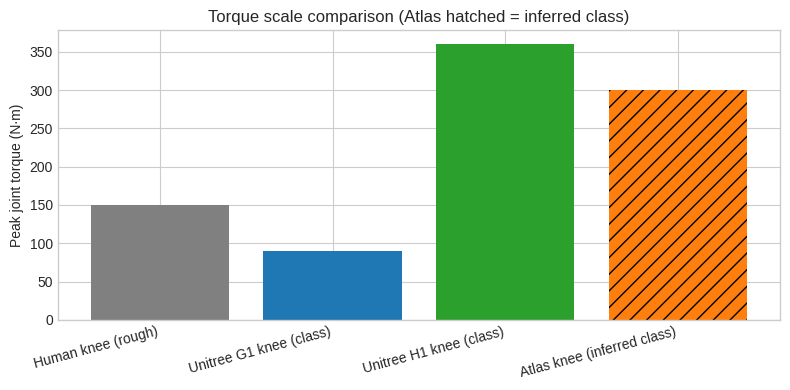

In [11]:
labels = ['Human knee (rough)', 'Unitree G1 knee (class)', 'Unitree H1 knee (class)', 'Atlas knee (inferred class)']
torques = [150, 90, 360, 300]  # Last is illustrative/inferred class, not official joint spec

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, torques, color=['gray', 'tab:blue', 'tab:green', 'tab:orange'])
bars[-1].set_hatch('//')
ax.set_ylabel('Peak joint torque (N·m)')
ax.set_title('Torque scale comparison (Atlas hatched = inferred class)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

In [12]:
def knee_torque_lift(payload_kg=10.0, robot_mass_kg=50.0, leg_length_m=0.45):
    g = 9.81
    total_mass = payload_kg + robot_mass_kg
    # very simplified static split between two legs
    tau_per_knee = (total_mass * g * leg_length_m) / 2.0

    print(f'Estimated static knee torque per leg: {tau_per_knee:.1f} N·m')
    print('Dynamic motions (running/jumping) can require much higher peak torque.')

knee_controls = {
    'payload_kg': FloatSlider(value=10.0, min=0.0, max=40.0, step=1.0, description='payload'),
    'robot_mass_kg': FloatSlider(value=50.0, min=20.0, max=120.0, step=1.0, description='robot kg'),
    'leg_length_m': FloatSlider(value=0.45, min=0.25, max=0.8, step=0.01, description='leg (m)')
}
knee_out = interactive_output(knee_torque_lift, knee_controls)
display(VBox([knee_controls['payload_kg'], knee_controls['robot_mass_kg'], knee_controls['leg_length_m'], knee_out]))

## 8) Buying checklist: what specs to inspect

Do not stop at one headline number. Here is what to look for and what critical questions to ask:

| # | Spec | What to ask / watch out for |
|---|------|-----------------------------|
| 1 | **Stall torque** | Is it measured at rated voltage? Is it thermally safe to hold? Some vendors quote a theoretical electrical stall that would burn the motor in seconds if held. |
| 2 | **Peak torque** | For how long? 0.5 s, 1 s, 10 s? Always compare vendors on the **same duration window**. Check whether the limit is thermal or electronic (current ceiling). |
| 3 | **Continuous torque** | The real working capacity. Check the assumed ambient temperature — a spec at 25 °C can drop 20–30% at 40 °C. |
| 4 | **Efficiency map** | Peak efficiency (often 90%+) only occurs in a narrow speed/torque band. Check $\eta$ at *your actual operating point*, not the headline figure in the title block. |
| 5 | **Gear ratio & backlash** | Backlash in arc-minutes tells you the positional dead-zone on reversal. For torque-controlled joints, < 1 arc-min is desirable. Ask for the *output-referred* backlash, not the motor-shaft value. |
| 6 | **Encoder type & resolution** | Incremental vs absolute? Resolution in CPR or bits? Is there a second output-side encoder for torque sensing? |
| 7 | **Thermal derating curve** | How does continuous torque drop with ambient temperature and duty cycle? Some datasheets omit this entirely — a significant red flag. |
| 8 | **Bus voltage & current limits** | Ensure compatibility with your power supply. Peak stall current must not trip your battery BMS, fuse, or inverter overcurrent protection. |

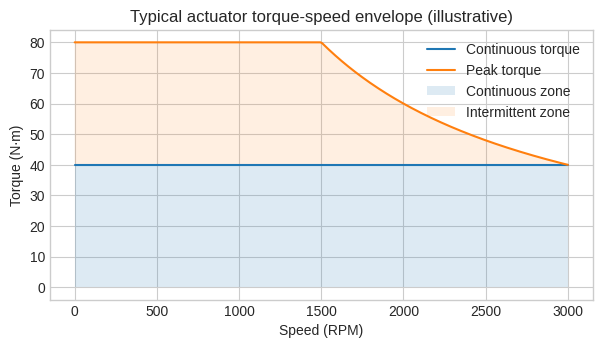

In [13]:
# Example: envelope style plot (illustrative)
speed = np.linspace(0, 3000, 300)
tau_cont = 40 * np.ones_like(speed)
tau_peak = 80 * np.ones_like(speed)
tau_peak[speed > 1500] = 80 * (1500 / speed[speed > 1500])

plt.figure(figsize=(7, 3.5))
plt.plot(speed, tau_cont, label='Continuous torque')
plt.plot(speed, tau_peak, label='Peak torque')
plt.fill_between(speed, 0, tau_cont, alpha=0.15, label='Continuous zone')
plt.fill_between(speed, tau_cont, tau_peak, alpha=0.12, label='Intermittent zone')
plt.xlabel('Speed (RPM)')
plt.ylabel('Torque (N·m)')
plt.title('Typical actuator torque-speed envelope (illustrative)')
plt.legend()
plt.show()

## 9) Safety around humans
Safety is not one setting; it is layered:
- Mechanical limits/stops
- Current and torque limits in firmware
- Model-based observers + **encoder** checks for anomalies
- E-stop path that removes drive power
- Conservative control gains and compliant behaviors near humans

For collaborative environments, prioritize predictable, bounded torque and robust fault handling.

In [ ]:
def torque_cap_demo(tau_cap=50.0):
    dt = 0.001
    t = np.arange(0, 2.0, dt)

    # same plant, with/without torque cap
    def sim(cap=None):
        Kp, Kd = 200, 10
        theta, omega = 0.0, 0.0
        ref = 1.5
        out = []
        for _ in t:
            tau = Kp * (ref - theta) - Kd * omega
            if cap is not None:
                tau = np.clip(tau, -cap, cap)
            alpha = tau
            omega += alpha * dt
            theta += omega * dt
            out.append(theta)
        return np.array(out)

    th_no_cap = sim(cap=None)
    th_cap = sim(cap=tau_cap)

    plt.figure(figsize=(7, 3.5))
    plt.plot(t, th_no_cap, label='No torque cap')
    plt.plot(t, th_cap, label=f'Torque cap ±{tau_cap:.0f} N·m')
    plt.axhline(1.5, linestyle='--', color='tab:red', label='Target')
    plt.xlabel('Time (s)')
    plt.ylabel('Angle (rad)')
    plt.title('Safety effect of torque limiting')
    plt.legend()
    plt.show()

torque_cap_controls = {
    'tau_cap': FloatSlider(value=50, min=5, max=200, step=5, description='τ cap')
}
torque_cap_out = interactive_output(torque_cap_demo, torque_cap_controls)
display(VBox([torque_cap_controls['tau_cap'], torque_cap_out]))

## 10) Simulation in MuJoCo and Isaac Sim vs real motors
Simulators are extremely useful, but they are approximations.

What simulation usually gets right:
- Rigid-body dynamics
- Kinematics and control logic behavior

What is often harder to match perfectly:
- Contact friction and impacts
- Motor heating/derating
- Driver/inverter nonlinearities
- Sensor noise, latency, **encoder** quantization
- Gear **backlash** and compliance

Bottom line: simulation is great for design and debugging, but final validation must be on hardware.

In [15]:
# Dependency-free mini simulation proxy (single joint)
def sim_proxy(applied_tau=20.0, damping=0.5):
    dt = 0.002
    t = np.arange(0, 3, dt)
    I = 1.5
    theta = 0.0
    omega = 0.0
    th = []

    for _ in t:
        alpha = (applied_tau - damping * omega) / I
        omega += alpha * dt
        theta += omega * dt
        th.append(theta)

    plt.figure(figsize=(7, 3.5))
    plt.plot(t, th)
    plt.xlabel('Time (s)')
    plt.ylabel('Joint angle (rad)')
    plt.title('Simple torque-driven joint simulation proxy')
    plt.show()

sim_proxy_controls = {
    'applied_tau': FloatSlider(value=20.0, min=-40.0, max=40.0, step=1.0, description='τ'),
    'damping': FloatSlider(value=0.5, min=0.0, max=5.0, step=0.1, description='damping')
}
sim_proxy_out = interactive_output(sim_proxy, sim_proxy_controls)
display(VBox([sim_proxy_controls['applied_tau'], sim_proxy_controls['damping'], sim_proxy_out]))

## Final takeaway
If you remember one thing: **Torque specs are central**.

When comparing robots/cars/actuators, do not stop at one headline number. Check:
- stall torque vs peak vs continuous
- efficiency at your operating point
- gearbox ratio and backlash
- encoder quality
- thermal limits and control strategy

That is how you move from marketing specs to real performance.